<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/). 
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA). 
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

Fri Aug 28 08:31:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.88                 KMD Version: 610.88        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060      WDDM  |   00000000:01:00.0  On |                  N/A |
| 40%   32C    P8             11W /  170W |     941MiB /  12288MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = "cuda" if torch.accelerator.is_available() else "cpu"
device

2.13.0+cu126


'cuda'

## 1. What are 3 areas in industry where computer vision is currently being used?

- *Healthcare*: Precision and proactive care
- *Finance*: Security and smart investments
- *Retail and e-commerce*: personalized shopping

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find. 

*Overfitting is related to both the complexity of the chosen model and how well it is optimized during training. A function class that is too large, in a suitable sense, relative to the dataset size is likely to overfit*

- Bottou, Léon; Bousquet, Olivier (2011-09-30), "The Tradeoffs of Large-Scale Learning"

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each. 
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

- **Hold-out (data)**: Rather than using all of our data for training, we split our dataset into training and testing data. Therefore, after training our model, we can test it on the testing data and evaluate it from the metrics we generated.
- **Cross-Validation (data)**: We can split our dataset into K groups (K-fold cross-validation). Then, we let one of the groups to be the testing set, and the others as the training set, and repeat the process until each individual group has been used as the testing set. This is a great, although costing, way of measuring if your architecture is suitable for the data and features that you will use to feed it.
- **Drop out (model)**: By applying a dropout, we "shutdown" some neurons while training (we set them to 0). This reduces, potentially, interdependent learning among units, which may have led to overfitting, at the cost of needing more epochs to converge.

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

I uploaded several images:
- An school bus: The CNN was trained to recognize american school buses, so it got it right
- A regular bus: The CNN was convinced it was a lady bug.
- A picture of two mugs of coffee: The CNN thought it was a red panda. It looked like it thought the mugs and the dark red color was their cheeks
- A picture of one espresso: The CNN got it right, as it was trained with similar images.

The CNN Explainer is very good at helping you visualize how each part of the network works (stride, pooling, ReLU...)

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [3]:
from torchvision import datasets
from torchvision.transforms import ToTensor

mnist_train_dataset = datasets.MNIST(root="data", 
                                     train=True,
                                     transform=ToTensor(),
                                     target_transform=None,
                                     download=True)
mnist_test_dataset = datasets.MNIST(root="data", 
                                     train=False,
                                     transform=ToTensor(),
                                     download=True)
classes_names = mnist_train_dataset.classes
len(classes_names)

10

## 6. Visualize at least 5 different samples of the MNIST training dataset.

torch.Size([1, 28, 28])

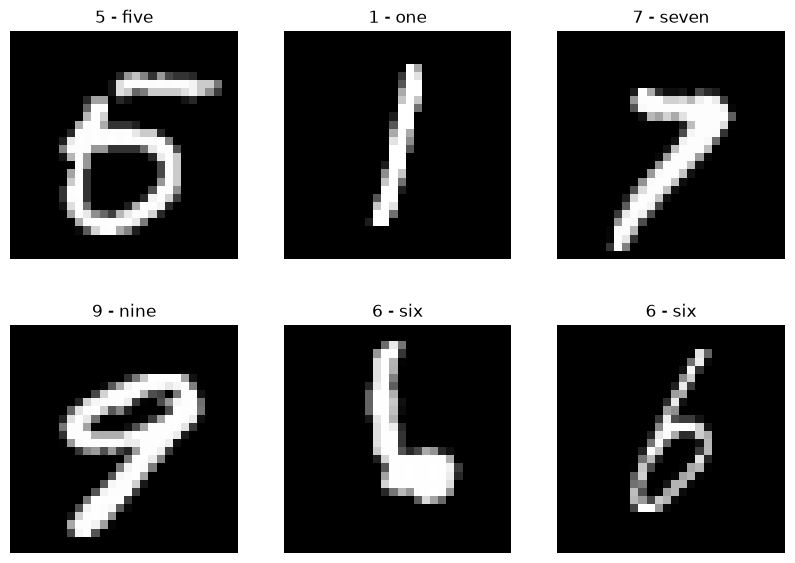

In [4]:
import matplotlib.pyplot as plt

torch.manual_seed(67)
nrows, ncols = 2, 3

fig = plt.figure(figsize=(10, 7))

for i in range(1, nrows * ncols + 1):
    rand_idx = torch.randint(1, len(mnist_train_dataset), size=[1]).item()
    image, label = mnist_train_dataset[rand_idx]
    fig.add_subplot(nrows, ncols, i)
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(classes_names[label])
    plt.axis(False)

image.shape

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [5]:
BATCH_SIZE = 32

train_dataloader = torch.utils.data.DataLoader(
    dataset=mnist_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = torch.utils.data.DataLoader(
    dataset=mnist_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Train batches: {len(train_dataloader)}")
print(f"Test batches : {len(test_dataloader)}")

Train batches: 1875
Test batches : 313


## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [6]:
from torch import nn

class MNISTModelV0(nn.Module):
    def __init__(self, input_features, output_features, hidden_units):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_features,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, 
                         stride=2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, output_features, 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, output_features, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, 
                         stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 7 * 7, # 28x28 -> MaxPool -> 14x14 -> MaxPool -> 7x7
                      out_features=output_features)
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        return self.classifier(x)

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [7]:
import torchmetrics

def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn: torchmetrics.Accuracy,
               optimizer: torch.optim.Optimizer,
               device: torch.device):
    # Metrics
    train_loss = 0
    accuracy_fn.to(device)
    accuracy_fn.reset()
    
    # Send model to target device and put it in training mode
    model.to(device)
    model.train()
    
    for batch, (X, y) in enumerate(data_loader):
        # Send data to target device
        X, y = X.to(device), y.to(device)
        
        # Forward pass
        y_logits = model(X)

        # Calculate loss and accuracy
        loss = loss_fn(y_logits, y)
        train_loss += loss.item()

        accuracy_fn(y_logits.argmax(dim=1), y)

        # Zero grad
        optimizer.zero_grad()

        # Loss backward
        loss.backward()

        # Optimizer step
        optimizer.step()

    train_loss /= len(data_loader)
    train_accuracy = accuracy_fn.compute().item()
    accuracy_fn.reset()

    print(f"Train Loss: {train_loss:.5f}, Train Accuracy: {train_accuracy:.2f}")

def test_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn: torchmetrics.Accuracy,
               device: torch.device):
    # Metrics
    test_loss = 0
    accuracy_fn.to(device)
    accuracy_fn.reset()
    
    # Send model to target device and put it in evaluation mode
    model.to(device)
    model.eval()
    
    with torch.inference_mode():
        for batch, (X, y) in enumerate(data_loader):
            # Send data to target device
            X, y = X.to(device), y.to(device)
            # Forward pass
            y_logits = model(X)
    
            # Calculate loss and accuracy
            test_loss += loss_fn(y_logits, y)
            accuracy_fn(y_logits.argmax(dim=1), y)

        test_loss /= len(data_loader)
        test_accuracy = accuracy_fn.compute().item()
        accuracy_fn.reset()
        
        print(f"Test Loss: {test_loss:.5f}, Test Accuracy: {test_accuracy:.2f}")

def print_time_elapsed(start, end):
    print(f"{end - start:.2f} seconds.")

In [8]:
loss_fn = nn.CrossEntropyLoss()
accuracy_fn = torchmetrics.Accuracy(task='multiclass', num_classes=len(classes_names)).to(device)

In [9]:
from tqdm.auto import tqdm
from timeit import default_timer as timer

torch.manual_seed(67)

epochs = 5

model_0_cpu = MNISTModelV0(input_features=1, output_features=len(classes_names), hidden_units=10)
optimizer = torch.optim.SGD(params=model_0_cpu.parameters(), lr=0.1)

train_cpu_start_time = timer()

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    train_step(model=model_0_cpu,
              data_loader=train_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              optimizer=optimizer,
              device="cpu")
    test_step(model=model_0_cpu,
              data_loader=test_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device="cpu")

train_cpu_end_time = timer()
print_time_elapsed(train_cpu_start_time, train_cpu_end_time)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
-------
Train Loss: 0.26590, Train Accuracy: 0.91
Test Loss: 0.07779, Test Accuracy: 0.98
Epoch: 1
-------
Train Loss: 0.07349, Train Accuracy: 0.98
Test Loss: 0.06395, Test Accuracy: 0.98
Epoch: 2
-------
Train Loss: 0.05615, Train Accuracy: 0.98
Test Loss: 0.04729, Test Accuracy: 0.98
Epoch: 3
-------
Train Loss: 0.04670, Train Accuracy: 0.99
Test Loss: 0.03936, Test Accuracy: 0.99
Epoch: 4
-------
Train Loss: 0.04166, Train Accuracy: 0.99
Test Loss: 0.04075, Test Accuracy: 0.99
82.27 seconds.


In [10]:
torch.manual_seed(67)

epochs = 5

model_0_gpu = MNISTModelV0(input_features=1, output_features=len(classes_names), hidden_units=10)
optimizer = torch.optim.SGD(params=model_0_gpu.parameters(), lr=0.1)

train_gpu_start_time = timer()

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    train_step(model=model_0_gpu,
              data_loader=train_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              optimizer=optimizer,
              device="cuda")
    test_step(model=model_0_gpu,
              data_loader=test_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device="cuda")

train_gpu_end_time = timer()
print_time_elapsed(train_gpu_start_time, train_gpu_end_time)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
-------
Train Loss: 0.26472, Train Accuracy: 0.91
Test Loss: 0.06996, Test Accuracy: 0.98
Epoch: 1
-------
Train Loss: 0.07196, Train Accuracy: 0.98
Test Loss: 0.06216, Test Accuracy: 0.98
Epoch: 2
-------
Train Loss: 0.05567, Train Accuracy: 0.98
Test Loss: 0.04434, Test Accuracy: 0.99
Epoch: 3
-------
Train Loss: 0.04666, Train Accuracy: 0.99
Test Loss: 0.03830, Test Accuracy: 0.99
Epoch: 4
-------
Train Loss: 0.04096, Train Accuracy: 0.99
Test Loss: 0.03659, Test Accuracy: 0.99
62.43 seconds.


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

In [11]:
def gen_predictions(model: nn.Module, data: list, device: torch.device = device):
    model.to(device)
    pred_probs = []

    model.eval()
    with torch.inference_mode():
        for sample in data:
            sample = torch.unsqueeze(sample, dim=0).to(device)
            pred_prob = model(sample)
            pred_probs.append(pred_prob.cpu())

        return torch.stack(pred_probs).squeeze()

tensor([[-11.9246,   2.1452,  -5.3324,  -6.5448,  20.3407,   1.4818,  -6.8018,
           0.6635,  -3.0707,   4.8072],
        [  3.1929, -12.1843,  -5.5242,  -4.5429,   1.5969,   4.2600,  18.1550,
         -11.3395,   3.9790,  -0.4464],
        [  1.4218,   2.4622,   2.6279,  -9.1107,  16.2248,  -7.9257,   0.4736,
          -0.8033,  -3.2576,  -7.6327],
        [ -3.4698,   1.6987,  21.7111,   2.3327,  -3.1160, -10.7754,  -5.6415,
           0.5432,  -1.3693,  -5.6307],
        [  0.4608,   3.4376,   0.5155,  -3.9012,   2.3981,  -0.0378,  13.6132,
         -11.2886,   1.9865,  -9.2519],
        [ -2.4057,  -0.9710,  -5.8045,   3.3425,   3.9707,   2.2911, -10.8791,
           8.1219,  -5.2536,   6.7043],
        [  4.0172,  -3.0732,  -3.0597, -11.7089,   9.5875,  -2.0878,  21.4991,
         -11.4587,  -1.0491,  -6.5020],
        [ 17.7775,  -7.2325,   2.1203,  -6.4322,  -7.1664,   0.0461,   3.6920,
          -8.4644,   5.9243,  -3.4180],
        [  1.3091,  -4.3063,   4.3833,   1.8453,

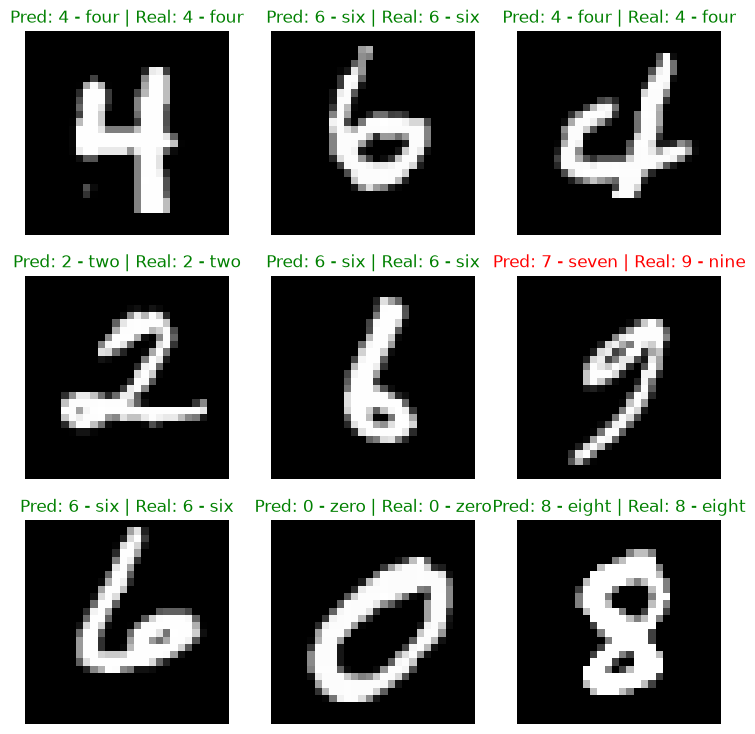

In [12]:
import random
torch.manual_seed(67)
rows = 3
cols = 3

test_samples = []
test_labels = []

for i in range(rows*cols):
    rand_idx = torch.randint(1, len(mnist_test_dataset), size=[1]).item()
    sample, label = mnist_test_dataset[rand_idx]
    
    test_samples.append(sample)
    test_labels.append(label)

test_predictions = gen_predictions(model=model_0_gpu, data=test_samples, device=device)
test_classes = test_predictions.argmax(dim=1)

print(test_predictions)
fig = plt.figure(figsize=(9, 9))
for idx in range(len(test_samples)):
    fig.add_subplot(rows, cols, idx+1)
    plt.imshow(test_samples[idx].squeeze(), cmap="gray")

    title_c = "g" if test_classes[idx] == test_labels[idx] else "r"
    plt.title(label=f"Pred: {classes_names[test_classes[idx]]} | Real: {classes_names[test_labels[idx]]}",
              c=title_c)
    plt.axis("off")
            

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

In [13]:
model_0_gpu.to(device)

y_preds = []

model_0_gpu.eval()
with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Making predictions"):
        X, y = X.to(device), y.to(device)
        y_logits = model_0_gpu(X)
        y_pred = y_logits.argmax(dim=1)
        y_preds.append(y_pred.cpu())

y_pred_tensor = torch.cat(y_preds)

Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

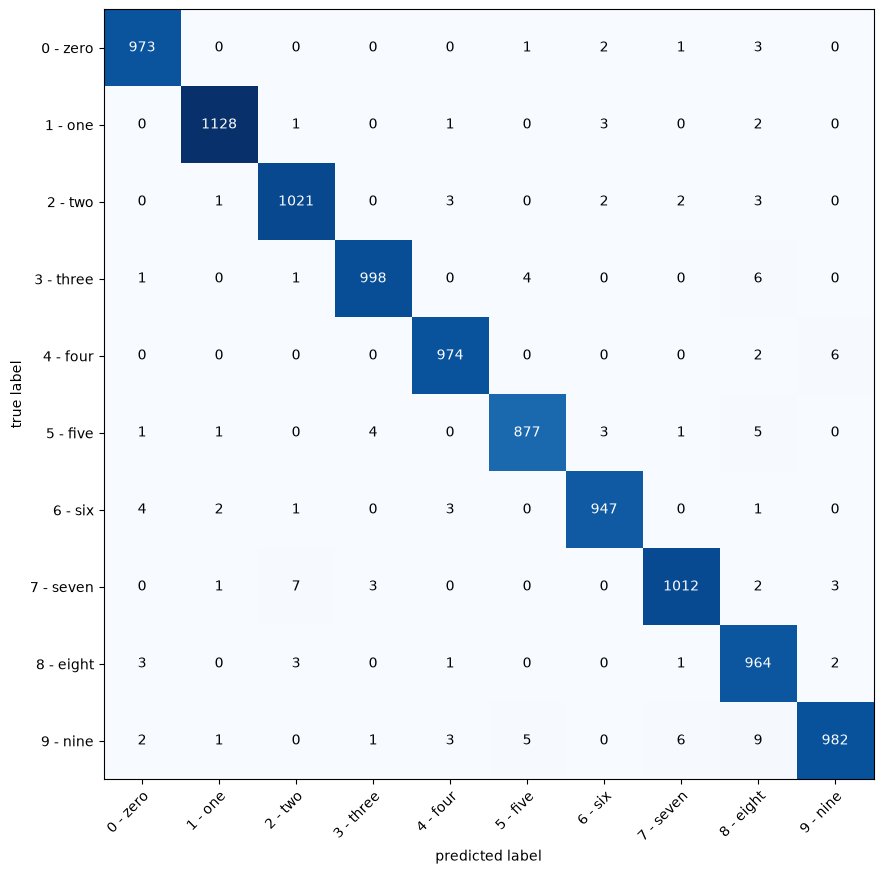

In [14]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

conf_mat = ConfusionMatrix(task='multiclass', num_classes=len(classes_names))
conf_mat_tensor = conf_mat(preds=y_pred_tensor, target=mnist_test_dataset.targets)

plot_confusion_matrix(conf_mat=conf_mat_tensor.numpy(), class_names=classes_names, figsize=(10,10))

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [15]:
torch.manual_seed(67)

rdm_tensor = torch.rand(size=(1, 3, 64, 64), dtype=torch.float)

def conv_layer_test(tensor: torch.Tensor, in_channels, out_channels, kernel_size, stride=1, padding=0):
    conv_layer = nn.Conv2d(in_channels=in_channels,
                           out_channels=out_channels,
                           kernel_size=kernel_size,
                           stride=stride,
                           padding=padding
                          )
    convoluted_tensor = conv_layer(tensor)
    print(f"Kernel {kernel_size}x{kernel_size}, convoluted tensor shape: {convoluted_tensor.shape}")

# Kernel size = 3x3
conv_layer_test(rdm_tensor, in_channels=3, out_channels=10, kernel_size=3)

# Kernel size = 5x5
conv_layer_test(rdm_tensor, in_channels=3, out_channels=10, kernel_size=5)

# Kernel size = 10x10
conv_layer_test(rdm_tensor, in_channels=3, out_channels=10, kernel_size=10)

Kernel 3x3, convoluted tensor shape: torch.Size([1, 10, 62, 62])
Kernel 5x5, convoluted tensor shape: torch.Size([1, 10, 60, 60])
Kernel 10x10, convoluted tensor shape: torch.Size([1, 10, 55, 55])


Kernel height and width are **inversely proportional** to the output height and width

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset. 
* Then plot some predictions where the model was wrong alongside what the label of the image should've been. 
* After visualing these predictions do you think it's more of a modelling error or a data error? 
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

In [16]:
import torchvision
from torchvision.transforms import ToTensor

train_data = torchvision.datasets.FashionMNIST(
    root="data",
    train=True,
    transform=ToTensor(),
    download=True
)

test_data = torchvision.datasets.FashionMNIST(
    root="data",
    train=False,
    transform=ToTensor(),
    download=True
)

class_names = train_data.classes
print(f"Data obtained. Classes: {class_names}")

Data obtained. Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [17]:
class FashionMNISTModelV2_1(nn.Module):
    def __init__(self, input_features, output_features, hidden_units):
        super().__init__()
        self.conv_layer_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_features,
                      out_channels=hidden_units,
                      kernel_size=5,
                      padding=2,
                     ),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=5,
                      padding=2,
                     ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_layer_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      padding=1,
                     ),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      padding=1,
                     ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 7 * 7,
                      out_features=output_features
            )
        )
    def forward(self, x):
        x = self.conv_layer_1(x)
        x = self.conv_layer_2(x)
        return self.classifier(x)

model_2 = FashionMNISTModelV2_1(input_features=1, output_features=len(class_names), hidden_units=8).to(device)
model_2

FashionMNISTModelV2_1(
  (conv_layer_1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): Conv2d(8, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_layer_2): Sequential(
    (0): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=392, out_features=10, bias=True)
  )
)

In [18]:
BATCH_SIZE = 64

train_dataloader = torch.utils.data.DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = torch.utils.data.DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

len(train_dataloader), len(test_dataloader)

(938, 157)

In [19]:
loss_fn = nn.CrossEntropyLoss()
accuracy_fn = torchmetrics.Accuracy(task='multiclass', num_classes=len(class_names))

optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

In [20]:
epochs = 5

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    train_step(
        model=model_2,
        data_loader=train_dataloader,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        optimizer=optimizer,
        device=device
    )
    test_step(
        model=model_2,
        data_loader=test_dataloader,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
-------
Train Loss: 0.82545, Train Accuracy: 0.70
Test Loss: 0.58229, Test Accuracy: 0.80
Epoch: 1
-------
Train Loss: 0.39930, Train Accuracy: 0.86
Test Loss: 0.38040, Test Accuracy: 0.86
Epoch: 2
-------
Train Loss: 0.35158, Train Accuracy: 0.87
Test Loss: 0.37618, Test Accuracy: 0.86
Epoch: 3
-------
Train Loss: 0.32448, Train Accuracy: 0.88
Test Loss: 0.35544, Test Accuracy: 0.87
Epoch: 4
-------
Train Loss: 0.30927, Train Accuracy: 0.89
Test Loss: 0.38049, Test Accuracy: 0.86


In [21]:
def pick_samples_from_dataset(dataset: torch.utils.data.Dataset,
                              n):
    samples = []
    labels = []
    
    rdm_indices = torch.randint(0, len(dataset), size=[n])
    for idx in rdm_indices:
        sample, label = dataset[idx]

        samples.append(sample)
        labels.append(label)

    return samples, labels

In [22]:
torch.manual_seed(67)

model_2.to(device)
model_2.eval()

bad_pred_images = []
bad_pred_labels = []
bad_pred_truths = []

with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Making predictions"):
        X, y = X.to(device), y.to(device)
        
        y_logits = model_2(X)
        y_pred = y_logits.argmax(dim=1)

        mismatch = torch.ne(y_pred, y)
        bad_pred_batch_images = X[mismatch]
        bad_pred_batch_labels = y_pred[mismatch]
        bad_pred_batch_truth = y[mismatch]
            
        bad_pred_images.append(bad_pred_batch_images.cpu())
        bad_pred_labels.append(bad_pred_batch_labels.cpu())
        bad_pred_truths.append(bad_pred_batch_truth.cpu())

Making predictions:   0%|          | 0/157 [00:00<?, ?it/s]

In [23]:
bad_pred_images_tensor = torch.cat(bad_pred_images)
bad_pred_labels_tensor = torch.cat([torch.atleast_1d(t) for t in bad_pred_labels], dim=0)
bad_pred_truths_tensor = torch.cat([torch.atleast_1d(t) for t in bad_pred_truths], dim=0)

print(f"Bad predictions tensor shape: {bad_pred_images_tensor.shape}")
print(f"Bad pred labels len: {len(bad_pred_labels_tensor)}")
print(f"Bad pred real label len: {len(bad_pred_truths_tensor)}")
print(f"Data loader size: {len(test_dataloader)}")

bad_pred_labels_tensor[1], bad_pred_truths_tensor[1]

Bad predictions tensor shape: torch.Size([1370, 1, 28, 28])
Bad pred labels len: 1370
Bad pred real label len: 1370
Data loader size: 157


(tensor(7), tensor(5))

In [24]:
def plot_samples(samples, rows, cols, truth_labels, pred_labels, class_names):
    fig = plt.figure(figsize=(16,16))
    for i in range(rows*cols):
        fig.add_subplot(rows, cols, i+1)
        plt.imshow(samples[i].squeeze(), "gray")

        truth_label, pred_label = truth_labels[i], pred_labels[i]
        label_color = "g" if truth_label == pred_label else "r"
        plt.title(label=f"Truth: {class_names[truth_label]} | Pred: {class_names[pred_label]}", color=label_color)
        plt.axis("off")

Seeing the results and comparing them to the previous ones, it's obvious that some labels are easy to confuse with eachother, like "Shirt" and "T-Shirt".

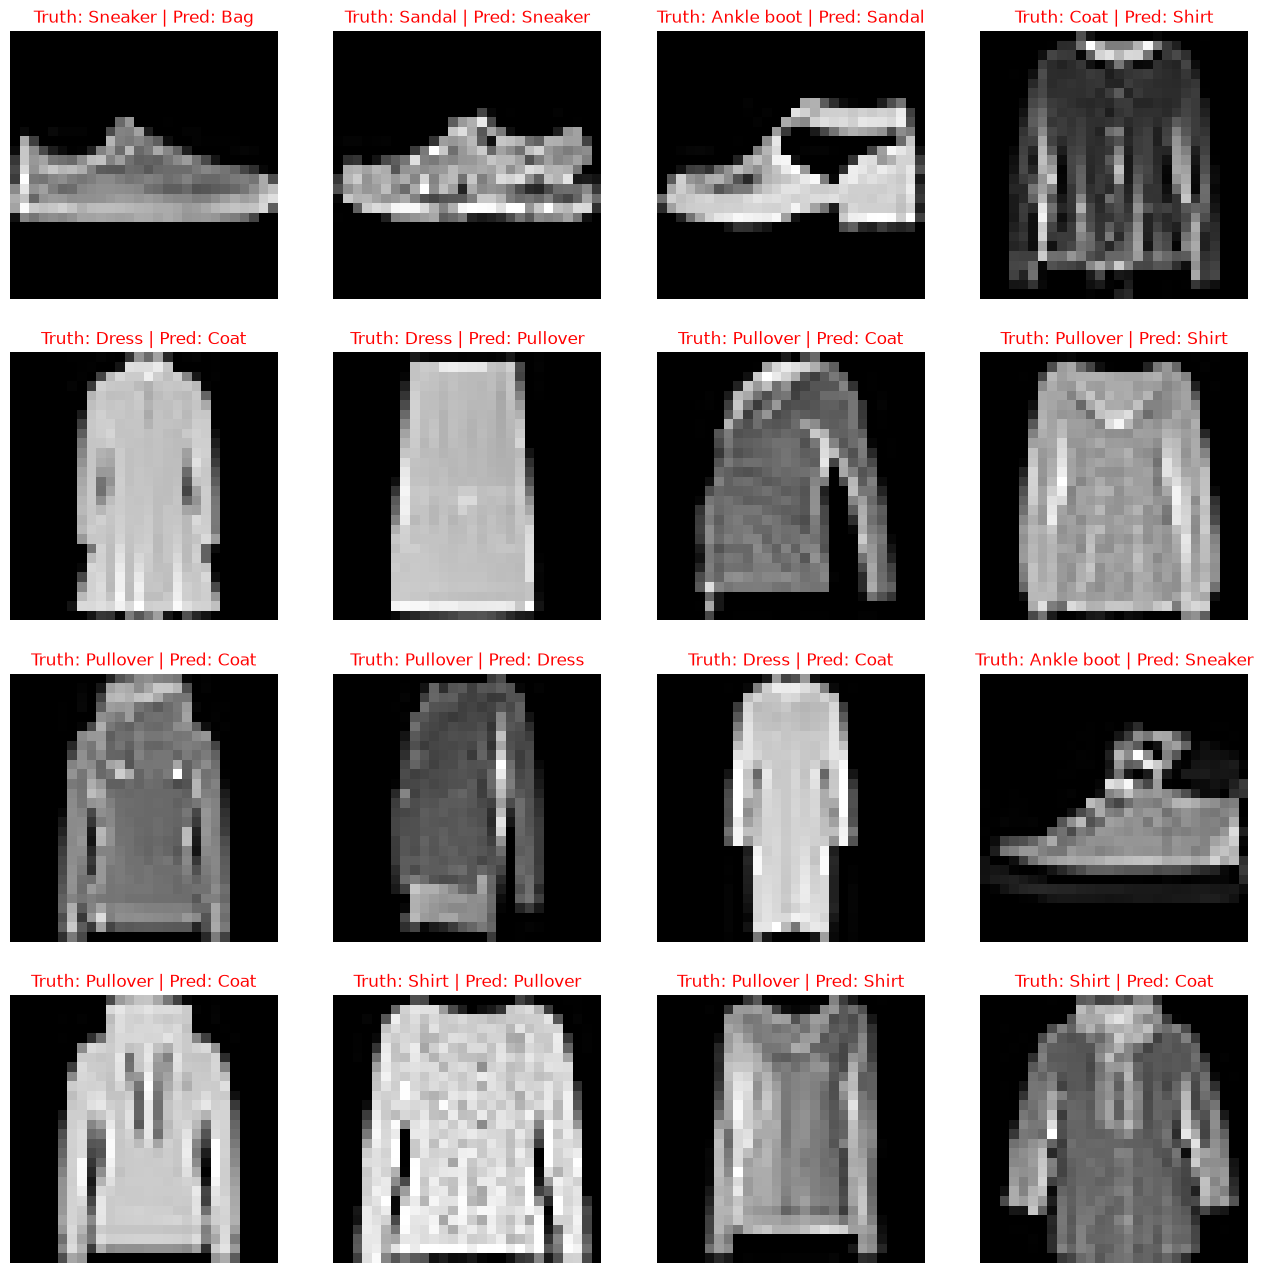

In [25]:
plot_samples(
    samples=bad_pred_images_tensor.numpy(),
    rows=4,
    cols=4,
    truth_labels=bad_pred_truths_tensor.numpy(),
    pred_labels=bad_pred_labels_tensor.numpy(),
    class_names=class_names)

Most of the mistakes make sense. It's easy to confuse "Ankle boots" with "Sneakers", "T-shirts" with "Shirts" and, in some cases, even "Dress" and "Coat".

If the dataset was colored, it would probably work a little better, but it could also lead to more overfitting if the model memorizes the colors.